# Betting Analysis — Calibration, Uncertainty & Kelly Criterion

Run this notebook **after** training `ProMatch_GNN.ipynb`.

Steps:
1. Load the trained DraftTransformer
2. Fit temperature scaling on the validation set (calibration)
3. MC Dropout — uncertainty intervals on the test set
4. Backtest: simulated P&L using Kelly sizing against hypothetical odds
5. Live match prediction helper

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader
from torch.amp import autocast
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, log_loss

from data.oracleselixir import load_raw, build_game_df, build_vocabularies
from models.draft_transformer import DraftTransformer, DraftDataset
from models.uncertainty import (
    TemperatureScaler, MCDropoutPredictor,
    betting_report, kelly_fraction, implied_prob, remove_margin
)

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
KEYS    = ["champ_ids", "team_ids", "side_ids", "role_ids", "pick_pos", "ban_ids", "patch_idx"]
print(f"Device: {device}")

Device: cuda


## 1. Load Data + Rebuild Splits (must match ProMatch_GNN.ipynb exactly)

In [2]:
raw     = load_raw("../src/data/oracleselixir", complete_only=True)
game_df = build_game_df(raw)
game_df = game_df.sort_values("date").reset_index(drop=True)

champ2idx, team2idx, patch2idx = build_vocabularies(game_df)

n       = len(game_df)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

train_df = game_df.iloc[:n_train].reset_index(drop=True)
val_df   = game_df.iloc[n_train:n_val].reset_index(drop=True)
test_df  = game_df.iloc[n_val:].reset_index(drop=True)

def make_loader(df, batch_size=256):
    return DataLoader(DraftDataset(df, champ2idx, team2idx, patch2idx),
                      batch_size=batch_size, num_workers=4, pin_memory=True)

val_loader  = make_loader(val_df)
test_loader = make_loader(test_df)
print(f"Val: {len(val_df):,}  Test: {len(test_df):,}")

Val: 9,350  Test: 9,350


## 2. Load Trained Model

In [3]:
MODEL_PATH = "../models/draft_transformer.pt"   # set in ProMatch_GNN.ipynb

model = DraftTransformer(
    num_champions=len(champ2idx), num_teams=len(team2idx), num_patches=len(patch2idx),
    champ_dim=64, team_dim=16, d_model=256, nhead=8, num_layers=4, dropout=0.1,
).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model loaded.")

Model loaded.


/tmp/ipykernel_1769/3820984838.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


## 3. Temperature Scaling — Calibration

Raw neural net probabilities are overconfident. Temperature scaling fits one parameter on the validation set to fix this.

Temperature fitted: T = 1.0642  (less confident than raw output)

Before calibration — log-loss: 0.6901
After  calibration — log-loss: 0.6899
ECE after calibration: 0.0166


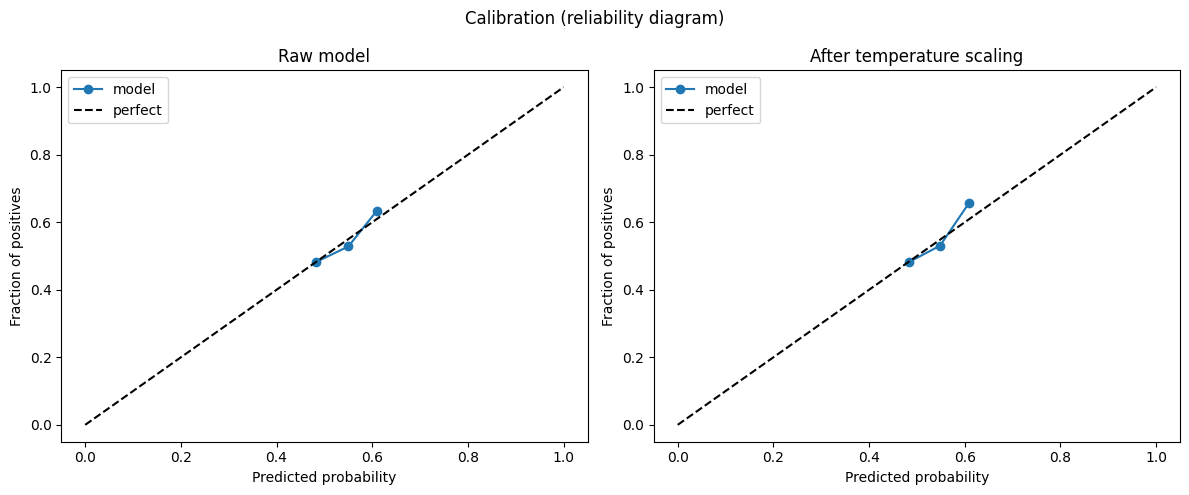

In [4]:
import importlib, models.uncertainty
importlib.reload(models.uncertainty)
from models.uncertainty import TemperatureScaler

def get_raw_probs(loader):
    model.eval()
    all_proba, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            inputs = {k: batch[k].to(device) for k in KEYS}
            with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=use_amp):
                logits = model(**inputs)
            all_proba.extend(torch.sigmoid(logits).float().cpu().tolist())
            all_labels.extend(batch["label"].tolist())
    return np.array(all_proba), np.array(all_labels)

val_probs,  val_labels  = get_raw_probs(val_loader)
test_probs, test_labels = get_raw_probs(test_loader)

scaler = TemperatureScaler()
scaler.fit(val_probs, val_labels)
cal_test_probs = scaler.calibrate(test_probs)

print(f"\nBefore calibration — log-loss: {log_loss(test_labels, test_probs):.4f}")
print(f"After  calibration — log-loss: {log_loss(test_labels, cal_test_probs):.4f}")
print(f"ECE after calibration: {scaler.calibration_error(test_probs, test_labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, probs, title in zip(axes,
                             [test_probs, cal_test_probs],
                             ["Raw model", "After temperature scaling"]):
    frac_pos, mean_pred = calibration_curve(test_labels, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label="model")
    ax.plot([0, 1], [0, 1], "k--", label="perfect")
    ax.set_title(title)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()
plt.suptitle("Calibration (reliability diagram)")
plt.tight_layout()
plt.show()


## 4. MC Dropout — Uncertainty Intervals

For each match: run 100 stochastic forward passes with dropout active.  
Wide interval → model unsure → skip the bet.

Median uncertainty (std): 0.0171
90th percentile std:      0.0197
Matches with std < 0.05:  100.0%  ← confident predictions
Matches with std < 0.08:  100.0%


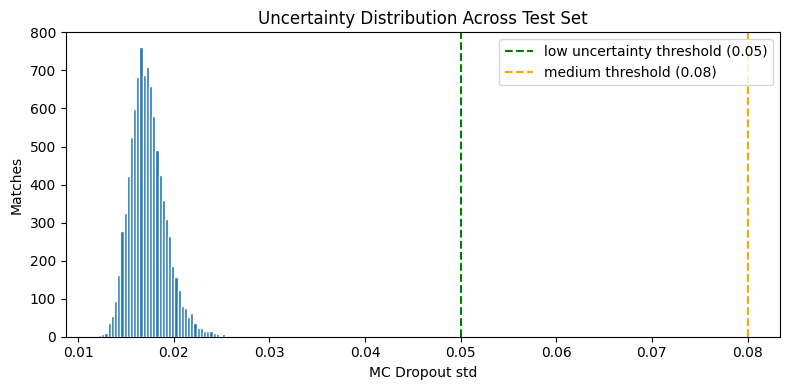

In [5]:
mc = MCDropoutPredictor(model, scaler=scaler, n_samples=100, use_amp=use_amp)

all_mean, all_std, all_lower, all_upper = [], [], [], []

for batch in test_loader:
    inputs = {k: batch[k] for k in KEYS}   # mc.predict moves to device internally
    result = mc.predict(inputs, device)
    all_mean.extend(result["mean"].tolist())
    all_std.extend(result["std"].tolist())
    all_lower.extend(result["lower95"].tolist())
    all_upper.extend(result["upper95"].tolist())

all_mean  = np.array(all_mean)
all_std   = np.array(all_std)
all_lower = np.array(all_lower)
all_upper = np.array(all_upper)

print(f"Median uncertainty (std): {np.median(all_std):.4f}")
print(f"90th percentile std:      {np.percentile(all_std, 90):.4f}")
print(f"Matches with std < 0.05:  {(all_std < 0.05).mean():.1%}  ← confident predictions")
print(f"Matches with std < 0.08:  {(all_std < 0.08).mean():.1%}")

# Distribution of uncertainty
plt.figure(figsize=(8, 4))
plt.hist(all_std, bins=50, edgecolor="white")
plt.axvline(0.05, color="green",  linestyle="--", label="low uncertainty threshold (0.05)")
plt.axvline(0.08, color="orange", linestyle="--", label="medium threshold (0.08)")
plt.xlabel("MC Dropout std")
plt.ylabel("Matches")
plt.title("Uncertainty Distribution Across Test Set")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Accuracy vs Uncertainty

Verify that low-uncertainty predictions are actually more accurate — if not, the uncertainty is not meaningful.

 max_std  games  accuracy
    0.02   8602  0.533481
    0.03   9350  0.533583
    0.04   9350  0.533583
    0.05   9350  0.533583
    0.06   9350  0.533583
    0.07   9350  0.533583
    0.08   9350  0.533583
    0.09   9350  0.533583
    0.10   9350  0.533583
    0.11   9350  0.533583
    0.12   9350  0.533583
    0.13   9350  0.533583
    0.14   9350  0.533583
    0.15   9350  0.533583
    0.16   9350  0.533583


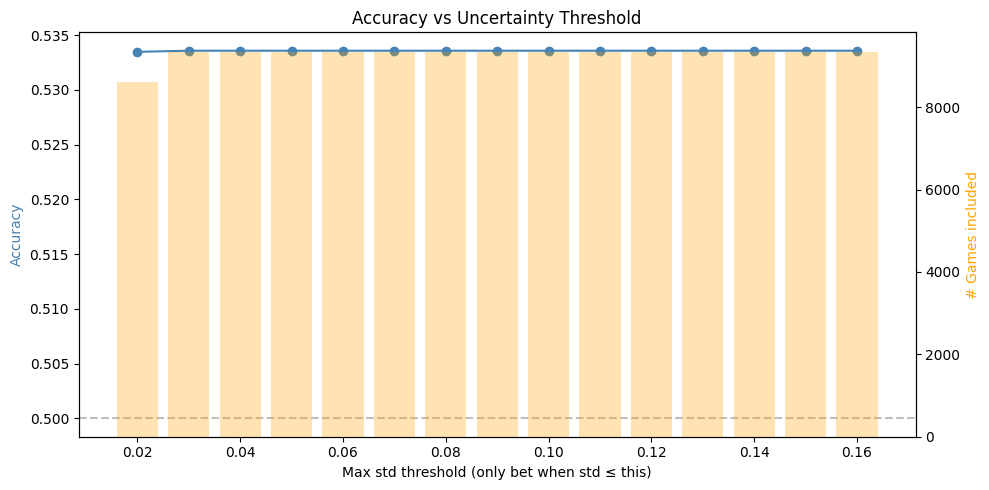

In [6]:
std_thresholds = np.arange(0.02, 0.16, 0.01)
rows = []
for thresh in std_thresholds:
    mask = all_std <= thresh
    if mask.sum() < 20:
        continue
    acc = ((all_mean[mask] > 0.5) == test_labels[mask]).mean()
    rows.append({"max_std": thresh, "games": mask.sum(), "accuracy": acc})

thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(thresh_df["max_std"], thresh_df["accuracy"], marker="o", color="steelblue", label="accuracy")
ax2.bar(thresh_df["max_std"], thresh_df["games"], width=0.008, alpha=0.3, color="orange", label="games")
ax1.set_xlabel("Max std threshold (only bet when std ≤ this)")
ax1.set_ylabel("Accuracy", color="steelblue")
ax2.set_ylabel("# Games included", color="orange")
ax1.set_title("Accuracy vs Uncertainty Threshold")
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Backtest — Simulated P&L with Kelly Sizing

Simulates betting on test-set matches using hypothetical odds.  
Real backtest requires historical bookmaker odds data (e.g. from Betfair or a scraper).

Total test matches : 9,350
Bets placed        : 3,656  (39.1% of matches)
Average edge       : 0.174
Average Kelly frac : 0.065
Average Elo prob   : 0.346
Average model prob : 0.545

Final bankroll : 0.000  (started at 1.0)
ROI            : -100.0%


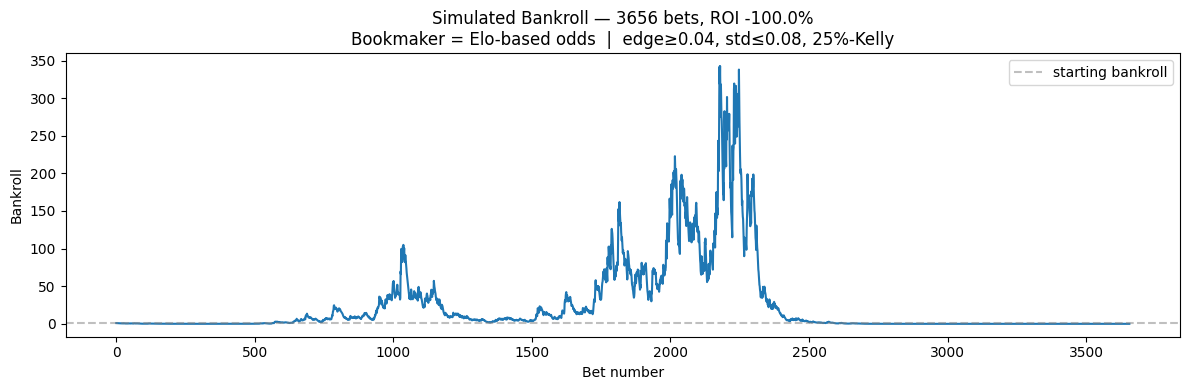

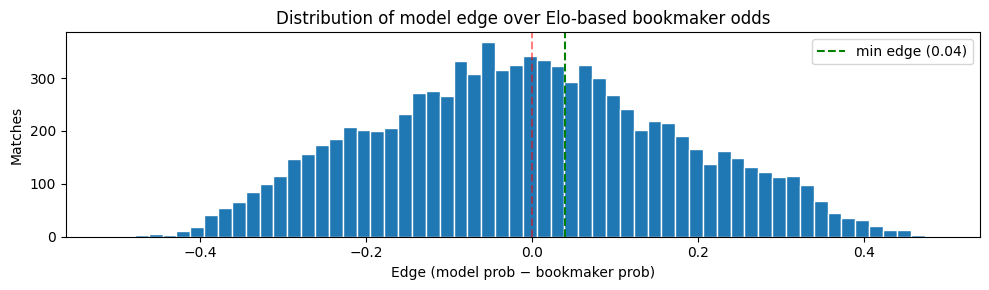

In [7]:
import sys, pickle
sys.path.append(os.path.abspath("../src"))
from models.elo import EloSystem

# ── Backtest parameters ──────────────────────────────────────────────────
MIN_EDGE      = 0.04    # minimum probability edge over bookmaker
MAX_STD       = 0.08    # skip if MC Dropout std exceeds this
KELLY_FRAC    = 0.25    # quarter-Kelly
BOOKMAKER_VIG = 0.05    # typical 5% margin
# ────────────────────────────────────────────────────────────────────────

# ── Bookmaker simulation ─────────────────────────────────────────────────
# Real bookmakers use team-strength models similar to Elo.
# We simulate their odds from saved Elo win probabilities — our edge
# is the EXTRA signal the draft gives us on top of what Elo already knows.
with open("../models/predraft/elo_ratings.pkl", "rb") as f:
    elo_state = pickle.load(f)

elo = EloSystem()
elo._ratings     = elo_state["ratings"]
elo._games       = elo_state["games"]
elo._team_league = elo_state.get("team_league", {})

# Compute Elo win probability for each test game
elo_probs = []
for _, row in test_df.iterrows():
    p = elo.win_probability(row["blue_team"], row["red_team"])
    elo_probs.append(p)
elo_probs = np.array(elo_probs)

# Bookmaker odds = Elo fair probability + vig
def elo_to_odds(elo_prob, vig=BOOKMAKER_VIG):
    book_prob = np.clip(elo_prob + vig / 2, 0.05, 0.95)
    return 1.0 / book_prob

# ── Build results dataframe ──────────────────────────────────────────────
results_df = test_df[["date", "league", "blue_team", "red_team", "blue_win"]].copy()
results_df["cal_prob"]    = all_mean
results_df["uncertainty"] = all_std
results_df["elo_prob"]    = elo_probs
results_df["sim_odds"]    = elo_to_odds(elo_probs)
results_df["book_prob"]   = 1 / results_df["sim_odds"]
results_df["edge"]        = results_df["cal_prob"] - results_df["book_prob"]
results_df["kelly"]       = results_df.apply(
    lambda r: kelly_fraction(r["cal_prob"], r["sim_odds"], fraction=KELLY_FRAC), axis=1)

# ── Filter to bets we would place ───────────────────────────────────────
bet_mask = (results_df["edge"] >= MIN_EDGE) & (results_df["uncertainty"] <= MAX_STD)
bets_df  = results_df[bet_mask].copy()

print(f"Total test matches : {len(results_df):,}")
print(f"Bets placed        : {len(bets_df):,}  ({len(bets_df)/len(results_df):.1%} of matches)")
if len(bets_df):
    print(f"Average edge       : {bets_df['edge'].mean():.3f}")
    print(f"Average Kelly frac : {bets_df['kelly'].mean():.3f}")
    print(f"Average Elo prob   : {bets_df['elo_prob'].mean():.3f}")
    print(f"Average model prob : {bets_df['cal_prob'].mean():.3f}")

# ── P&L simulation ───────────────────────────────────────────────────────
bankroll = 1.0
bankroll_history = [bankroll]
for _, row in bets_df.iterrows():
    stake = bankroll * row["kelly"]
    if row["blue_win"] == 1:
        bankroll += stake * (row["sim_odds"] - 1)
    else:
        bankroll -= stake
    bankroll_history.append(bankroll)

roi = (bankroll - 1.0) * 100
print(f"\nFinal bankroll : {bankroll:.3f}  (started at 1.0)")
print(f"ROI            : {roi:+.1f}%")

plt.figure(figsize=(12, 4))
plt.plot(bankroll_history)
plt.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="starting bankroll")
plt.xlabel("Bet number")
plt.ylabel("Bankroll")
plt.title(
    f"Simulated Bankroll — {len(bets_df)} bets, ROI {roi:+.1f}%\n"
    f"Bookmaker = Elo-based odds  |  edge≥{MIN_EDGE}, std≤{MAX_STD}, {KELLY_FRAC*100:.0f}%-Kelly"
)
plt.legend()
plt.tight_layout()
plt.show()

# ── Edge distribution ────────────────────────────────────────────────────
plt.figure(figsize=(10, 3))
plt.hist(results_df["edge"], bins=60, edgecolor="white")
plt.axvline(MIN_EDGE, color="green", linestyle="--", label=f"min edge ({MIN_EDGE})")
plt.axvline(0, color="red", linestyle="--", alpha=0.5)
plt.xlabel("Edge (model prob − bookmaker prob)")
plt.ylabel("Matches")
plt.title("Distribution of model edge over Elo-based bookmaker odds")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Live Match Prediction

Paste in a real match's draft to get a calibrated probability + uncertainty interval.

──────────────────────────────────────────────────
  T1 (Blue)  vs  Gen.G (Red)
  Patch: 15.10
──────────────────────────────────────────────────
  Blue win probability:  53.9%
  95% interval:          [51.3%, 56.2%]
  Uncertainty (std):     0.0148  ✓ confident

  Bookmaker odds (blue): 1.85
  Implied prob:          54.0%
  Edge:                  -0.1%
  Kelly stake:           0.0% of bankroll
  → SKIP — no edge
──────────────────────────────────────────────────


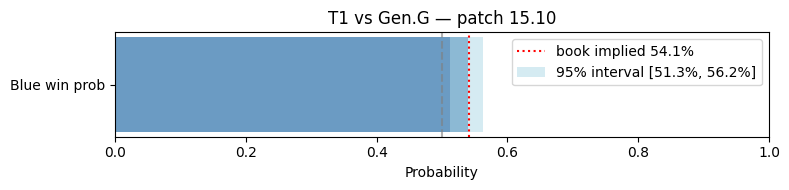

{'mean': 0.539100706577301,
 'std': 0.014770952053368092,
 'lower95': 0.5127551555633545,
 'upper95': 0.5624406933784485}

In [8]:
from models.draft_transformer import _row_to_tensors

def predict_match(
    blue_team, blue_picks, blue_bans,   # lists of 5 champion names
    red_team,  red_picks,  red_bans,
    patch: str,
    bookmaker_odds_blue: float = None,   # optional: decimal odds for blue side win
    n_mc_samples: int = 100,
):
    """
    Predict a live match from its draft.

    Args:
        blue_picks / red_picks: list of 5 champion names in role order [top, jng, mid, bot, sup]
        blue_bans  / red_bans:  list of 5 banned champion names
        patch:                  patch string, e.g. "15.10"
        bookmaker_odds_blue:    decimal odds for blue side to win (optional, for edge calc)

    Example:
        predict_match(
            blue_team = "T1",
            blue_picks= ["Jayce", "Vi", "Orianna", "Jinx", "Nautilus"],
            blue_bans = ["Zed", "Leblanc", "Thresh", "Aphelios", "Syndra"],
            red_team  = "Gen.G",
            red_picks = ["Gnar", "Hecarim", "Azir", "Kaisa", "Lulu"],
            red_bans  = ["Renekton", "Graves", "Viktor", "Jhin", "Nami"],
            patch     = "15.10",
            bookmaker_odds_blue = 1.85,
        )
    """
    ROLES = ["top", "jng", "mid", "bot", "sup"]
    row = {
        "blue_team": blue_team, "red_team": red_team,
        "patch": patch, "blue_win": 0,   # dummy label
    }
    for i, role in enumerate(ROLES):
        row[f"blue_{role}"] = blue_picks[i]
        row[f"red_{role}"]  = red_picks[i]
        row[f"blue_pick_order_{role}"] = i
        row[f"red_pick_order_{role}"]  = i
    for i in range(5):
        row[f"blue_ban{i+1}"] = blue_bans[i]
        row[f"red_ban{i+1}"]  = red_bans[i]

    sample = _row_to_tensors(row, champ2idx, team2idx, patch2idx)
    batch  = {k: sample[k].unsqueeze(0) for k in KEYS}

    # MC Dropout prediction
    result = mc.predict(batch, device)
    mean   = float(result["mean"][0])
    std    = float(result["std"][0])
    lo     = float(result["lower95"][0])
    hi     = float(result["upper95"][0])

    print(f"{'─'*50}")
    print(f"  {blue_team} (Blue)  vs  {red_team} (Red)")
    print(f"  Patch: {patch}")
    print(f"{'─'*50}")
    print(f"  Blue win probability:  {mean:.1%}")
    print(f"  95% interval:          [{lo:.1%}, {hi:.1%}]")
    print(f"  Uncertainty (std):     {std:.4f}  ", end="")
    print("✓ confident" if std <= MAX_STD else "⚠ uncertain — consider skipping")
    print()

    if bookmaker_odds_blue:
        report = betting_report(mean, bookmaker_odds_blue, std,
                                min_edge=MIN_EDGE, max_std=MAX_STD, kelly_frac=KELLY_FRAC)
        print(f"  Bookmaker odds (blue): {bookmaker_odds_blue}")
        print(f"  Implied prob:          {report['book_prob']:.1%}")
        print(f"  Edge:                  {report['edge']:+.1%}")
        print(f"  Kelly stake:           {report['kelly_frac']:.1%} of bankroll")
        print(f"  → {report['action']}")
    print(f"{'─'*50}")

    # Visual
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.barh(["Blue win prob"], [mean], color="steelblue", alpha=0.8)
    ax.barh(["Blue win prob"], [hi - lo], left=lo, color="lightblue",
            alpha=0.5, label=f"95% interval [{lo:.1%}, {hi:.1%}]")
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.6)
    if bookmaker_odds_blue:
        ax.axvline(implied_prob(bookmaker_odds_blue), color="red",
                   linestyle=":", label=f"book implied {implied_prob(bookmaker_odds_blue):.1%}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Probability")
    ax.legend(loc="upper right")
    ax.set_title(f"{blue_team} vs {red_team} — patch {patch}")
    plt.tight_layout()
    plt.show()

    return {"mean": mean, "std": std, "lower95": lo, "upper95": hi}


# ── Example call — replace with the real match draft ──────────────────────
predict_match(
    blue_team  = "T1",
    blue_picks = ["Jayce",    "Vi",       "Orianna", "Jinx",     "Nautilus"],
    blue_bans  = ["Zed",      "LeBlanc",  "Thresh",  "Aphelios", "Syndra"],
    red_team   = "Gen.G",
    red_picks  = ["Gnar",     "Hecarim",  "Azir",    "Kaisa",    "Lulu"],
    red_bans   = ["Renekton", "Graves",   "Viktor",  "Jhin",     "Nami"],
    patch      = "15.10",
    bookmaker_odds_blue = 1.85,
)